# Political Stance Shift Audit

Companion to `Political_fairness_audit.ipynb`. Where the fairness audit asked
*do summaries preserve moral framing equally across leanings?*, this notebook asks
**does the LLM systematically shift the political stance itself?**

Pipeline (run from the repo root before opening this notebook):

```
python -m political_shift.build_texts     # 1. extract articles + summaries -> texts.parquet
python -m political_shift.score_texts     # 2. score with politicalBiasBERT  -> stance_scores.parquet
python -m political_shift.build_shifts    # 3. join into per-summary shifts  -> shifts.parquet
```

Stance scores have 2 values:

`direction = P(right) - P(left)` — [-1, 1] where **+1 = right-leaning**, **-1 = left-leaning**, 0 = balanced

`polarization = 1 - P(center)` — [0, 1] where 0 = fully centrist, 1 = no centrist probability


## 1. Load `shifts.parquet`


In [10]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SHIFTS_PATH = REPO_ROOT / 'political_shift' / 'data' / 'shifts.parquet'

shifts = pd.read_parquet(SHIFTS_PATH)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print(f'shifts: {len(shifts):,} rows  '
      f"({shifts['model'].nunique()} models x "
      f"{shifts['method'].nunique()} methods x "
      f"{shifts['article_id'].nunique()} articles x "
      f"{shifts['seed'].nunique()} seeds)")

PREVIEW_COLS = ['article_id', 'leaning', 'method', 'model', 'seed',
                'article_direction', 'summary_direction', 'direction_shift',
                'article_polarization', 'summary_polarization', 'polarization_shift']
shifts[PREVIEW_COLS].head(3)


shifts: 10,882 rows  (3 models x 5 methods x 180 articles x 5 seeds)


,article_id,leaning,method,model,seed,article_direction,summary_direction,direction_shift,article_polarization,summary_polarization,polarization_shift
0,allsides_abortion_c_2,center,class,DeepSeek-R1-Distill-Qwen-32B,311,0.152584,0.011343,-0.141241,0.198097,0.803946,0.605849
1,allsides_abortion_c_2,center,class,DeepSeek-R1-Distill-Qwen-32B,345,0.152584,0.018125,-0.134459,0.198097,0.251924,0.053827
2,allsides_abortion_c_2,center,class,DeepSeek-R1-Distill-Qwen-32B,49,0.152584,0.064671,-0.087914,0.198097,0.409590,0.211493


## 2. Mean shift by (leaning, method, model) with seed-std

Each summary is a `(article, method, model, seed)` cell. For each
`(leaning, method, model)` combination we report the mean shift across articles
and seeds, plus the standard deviation across seeds-per-article for both metrics:

- **direction_shift** = `summary_direction − article_direction`, where `direction = P(left) − P(right)`
- **polarization_shift** = `summary_polarization − article_polarization`, where `polarization = 1 − P(center)`


In [11]:
# Per-article mean and seed-std (collapses the 5 seeds for that article).
per_article = (
    shifts.groupby(['model', 'method', 'leaning', 'article_id'])
    .agg(
        dir_mean=('direction_shift', 'mean'),
        dir_std=('direction_shift', 'std'),
        pol_mean=('polarization_shift', 'mean'),
        pol_std=('polarization_shift', 'std'),
    )
    .reset_index()
)

# Then aggregate across articles for the (model, method, leaning) cell.
shift_table = (
    per_article.groupby(['model', 'method', 'leaning'])
    .agg(
        mean_direction=('dir_mean', 'mean'),
        direction_seed_std=('dir_std', 'mean'),
        mean_polarization=('pol_mean', 'mean'),
        polarization_seed_std=('pol_std', 'mean'),
        n_articles=('article_id', 'nunique'),
    )
    .round(4)
    .reset_index()
)


In [12]:
def fmt_dir(row):
    return f"{row['mean_direction']:+.3f} (s {row['direction_seed_std']:.3f})"

def fmt_pol(row):
    return f"{row['mean_polarization']:+.3f} (s {row['polarization_seed_std']:.3f})"

shift_table['dir_cell'] = shift_table.apply(fmt_dir, axis=1)
shift_table['pol_cell'] = shift_table.apply(fmt_pol, axis=1)

print("=== Direction shift  (P_left − P_right) ===")
compact_dir = (
    shift_table
    .pivot_table(index=['model', 'method'], columns='leaning', values='dir_cell', aggfunc='first')
    [['left', 'center', 'right']]
)
display(compact_dir)

print("\n=== Polarization shift  (1 − P_center) ===")
compact_pol = (
    shift_table
    .pivot_table(index=['model', 'method'], columns='leaning', values='pol_cell', aggfunc='first')
    [['left', 'center', 'right']]
)
display(compact_pol)


=== Direction shift  (P_left − P_right) ===


leaning                                           left            center             right
model                        method                                                       
DeepSeek-R1-Distill-Qwen-32B class    +0.153 (s 0.195)  +0.175 (s 0.349)  -0.109 (s 0.326)
                             cot      +0.300 (s 0.171)  -0.121 (s 0.170)  -0.257 (s 0.190)
                             oracle   +0.256 (s 0.333)  +0.174 (s 0.251)  -0.079 (s 0.238)
                             simple   +0.182 (s 0.259)  +0.141 (s 0.239)  -0.130 (s 0.216)
                             vanilla  +0.336 (s 0.290)  +0.162 (s 0.246)  -0.074 (s 0.283)
Meta-Llama-3-70B-Instruct    class    +0.393 (s 0.181)  +0.082 (s 0.196)  -0.072 (s 0.143)
                             cot      +0.368 (s 0.214)  +0.257 (s 0.140)  +0.077 (s 0.174)
                             oracle   +0.330 (s 0.212)  +0.200 (s 0.164)  +0.021 (s 0.170)
                             simple   +0.213 (s 0.145)  +0.074 (s 0.163)  -0.073 (s 0.125)
                             vanilla  +0.325 (s 0.118)  +0.167 (s 0.102)  -0.002 (s 0.087)
c4ai-command-r-plus-4bit     class    +0.301 (s 0.218)  -0.029 (s 0.235)  -0.141 (s 0.143)
                             cot      +0.219 (s 0.296)  +0.096 (s 0.225)  -0.070 (s 0.238)
                             oracle   +0.275 (s 0.313)  +0.072 (s 0.234)  +0.012 (s 0.281)
                             simple   +0.182 (s 0.336)  +0.039 (s 0.214)  +0.027 (s 0.245)
                             vanilla  +0.319 (s 0.230)  +0.176 (s 0.204)  -0.051 (s 0.176)


=== Polarization shift  (1 − P_center) ===


leaning                                           left            center             right
model                        method                                                       
DeepSeek-R1-Distill-Qwen-32B class    -0.002 (s 0.058)  +0.231 (s 0.129)  -0.058 (s 0.096)
                             cot      -0.629 (s 0.255)  -0.325 (s 0.275)  -0.604 (s 0.265)
                             oracle   -0.032 (s 0.080)  +0.277 (s 0.089)  -0.011 (s 0.075)
                             simple   -0.026 (s 0.089)  +0.271 (s 0.078)  -0.006 (s 0.072)
                             vanilla  -0.036 (s 0.088)  +0.250 (s 0.097)  -0.031 (s 0.088)
Meta-Llama-3-70B-Instruct    class    -0.130 (s 0.074)  +0.211 (s 0.076)  -0.037 (s 0.047)
                             cot      -0.073 (s 0.065)  +0.266 (s 0.059)  -0.025 (s 0.059)
                             oracle   -0.080 (s 0.065)  +0.256 (s 0.061)  -0.036 (s 0.061)
                             simple   -0.057 (s 0.048)  +0.239 (s 0.073)  -0.027 (s 0.048)
                             vanilla  -0.035 (s 0.041)  +0.223 (s 0.052)  -0.007 (s 0.033)
c4ai-command-r-plus-4bit     class    -0.102 (s 0.088)  +0.196 (s 0.096)  -0.068 (s 0.074)
                             cot      -0.043 (s 0.095)  +0.268 (s 0.099)  -0.037 (s 0.086)
                             oracle   -0.051 (s 0.081)  +0.252 (s 0.079)  -0.046 (s 0.088)
                             simple   -0.056 (s 0.095)  +0.244 (s 0.100)  -0.051 (s 0.073)
                             vanilla  -0.034 (s 0.082)  +0.269 (s 0.078)  -0.004 (s 0.053)

## 3. Distribution of shifts per leaning x method (Llama-3-70B)

Boxplots of `direction_shift` and `polarization_shift` across all (article, seed) cells.
The fairness question is whether the boxes for left/center/right sit on top of each other
inside a given method panel.


/var/folders/q_/lwblb1qs4ms386qzk_239jqc0000gn/T/ipykernel_71297/1768650351.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=leanings, patch_artist=True, widths=0.6, showmeans=True)
/var/folders/q_/lwblb1qs4ms386qzk_239jqc0000gn/T/ipykernel_71297/1768650351.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=leanings, patch_artist=True, widths=0.6, showmeans=True)
/var/folders/q_/lwblb1qs4ms386qzk_239jqc0000gn/T/ipykernel_71297/1768650351.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=leanings, patch_artist=True, widths=0

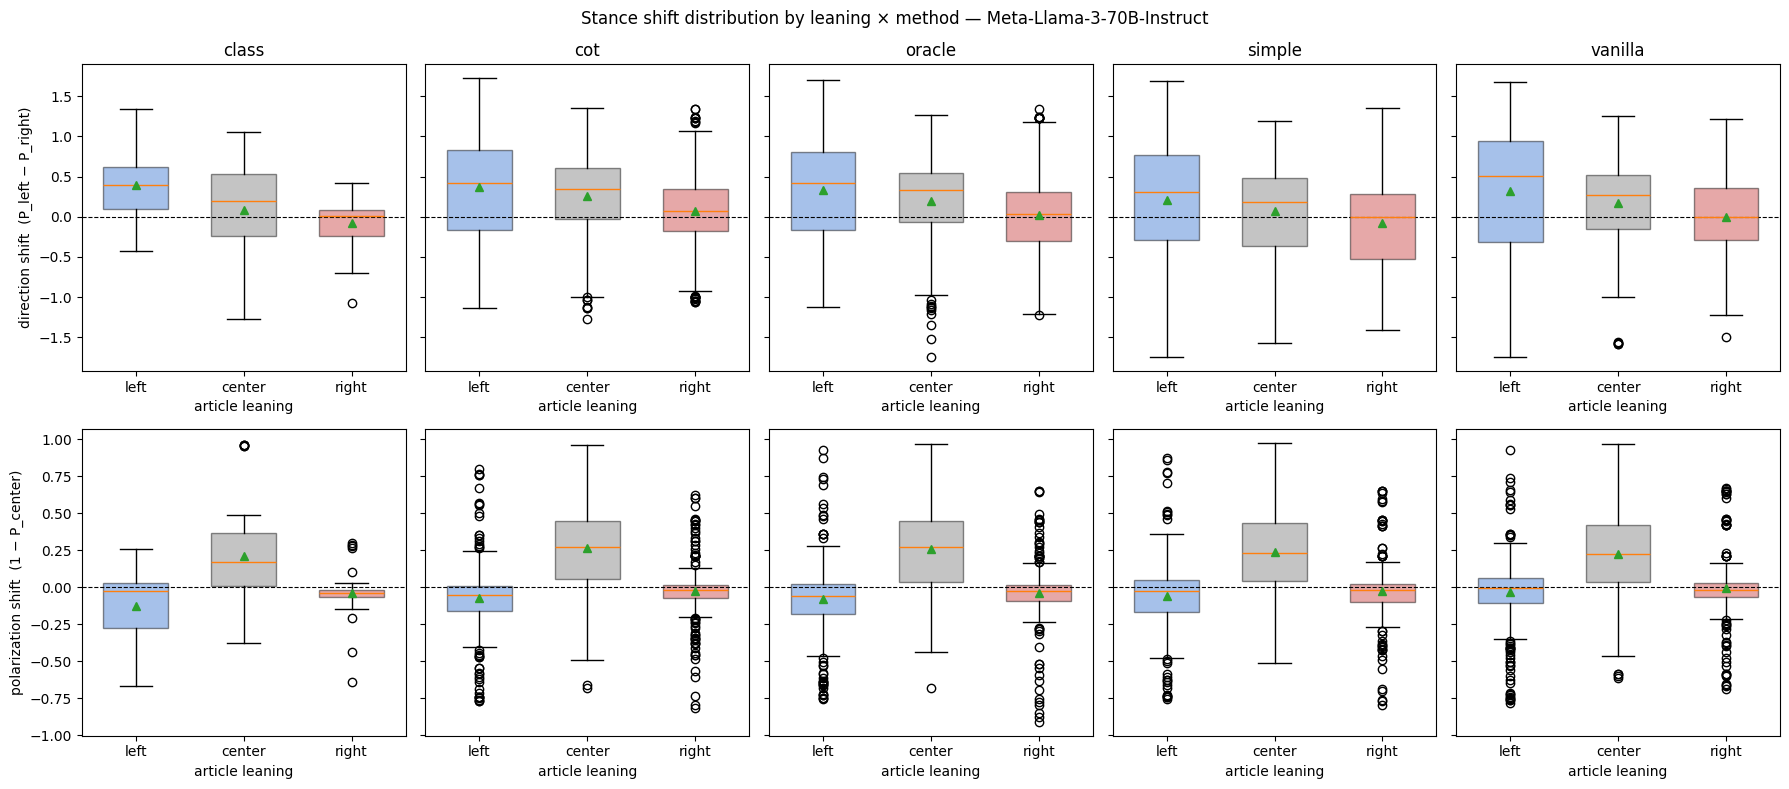

In [13]:
LLAMA = 'Meta-Llama-3-70B-Instruct'
llama = shifts[shifts['model'] == LLAMA].copy()

methods = sorted(llama['method'].unique())
leanings = ['left', 'center', 'right']
leaning_colors = {'left': '#3b76d1', 'center': '#7e7e7e', 'right': '#c83e3e'}

metrics = [
    ('direction_shift',    'direction shift  (P_left − P_right)'),
    ('polarization_shift', 'polarization shift  (1 − P_center)'),
]

fig, axes = plt.subplots(
    len(metrics), len(methods),
    figsize=(3.6 * len(methods), 4 * len(metrics)),
    sharey='row',
)

for row_idx, (metric, ylabel) in enumerate(metrics):
    for col_idx, method in enumerate(methods):
        ax = axes[row_idx][col_idx]
        sub = llama[llama['method'] == method]
        data = [sub.loc[sub['leaning'] == lean, metric].values for lean in leanings]
        bp = ax.boxplot(data, labels=leanings, patch_artist=True, widths=0.6, showmeans=True)
        for patch, lean in zip(bp['boxes'], leanings):
            patch.set_facecolor(leaning_colors[lean])
            patch.set_alpha(0.45)
        ax.axhline(0, color='k', lw=0.8, ls='--')
        if col_idx == 0:
            ax.set_ylabel(ylabel)
        if row_idx == 0:
            ax.set_title(method)
        ax.set_xlabel('article leaning')

fig.suptitle(f'Stance shift distribution by leaning × method — {LLAMA}')
fig.tight_layout()
plt.show()


## 4. Pearson corr |shift| vs moral_retention, by model:

Sticking the political shift next to the per-summary moral-count metrics lets us
ask follow-ups like *does losing moral language go hand in hand with a stance
swing?* `data_loader.build_full_long()` gives us one row per
`(model, article, prompting_method, metric)`. We average shift across seeds (since
the moral metrics in the pickles are already averaged over seeds), then merge on
`(model, article, prompting_method)`.


In [14]:
from data_loader import build_full_long, allsides_only

long_df = build_full_long()
long_df = allsides_only(long_df)
print(f'long_df (AllSides rows): {len(long_df):,}')


long_df (AllSides rows): 17,280


In [15]:
# Average shift over seeds to match the pickle granularity.
shift_avg = (
    shifts.groupby(['model', 'method', 'article_id'])
    .agg(
        direction_mean=('direction_shift', 'mean'),
        direction_std=('direction_shift', 'std'),
        polarization_mean=('polarization_shift', 'mean'),
        polarization_std=('polarization_shift', 'std'),
        article_direction=('article_direction', 'mean'),
        summary_direction=('summary_direction', 'mean'),
        article_polarization=('article_polarization', 'mean'),
        summary_polarization=('summary_polarization', 'mean'),
        n_seeds=('seed', 'nunique'),
    )
    .reset_index()
    .rename(columns={'method': 'prompting_method', 'article_id': 'article'})
)
print(f'shift_avg: {len(shift_avg):,} rows  (one per model × method × article)')


shift_avg: 2,247 rows  (one per model × method × article)


In [16]:
merged = long_df.merge(
    shift_avg,
    on=['model', 'article', 'prompting_method'],
    how='left',
)

# Sanity: every AllSides row should now have a direction_mean.
coverage = (
    merged.query("metric == 'moral_count'")
    .groupby(['model', 'prompting_method'])['direction_mean']
    .apply(lambda s: s.notna().sum())
    .unstack('prompting_method')
)
coverage


prompting_method,class,cot,oracle,original,simple,vanilla
model,,,,,,
DeepSeek-R1-Distill-Qwen-32B,29,180,180,0,180,180
Meta-Llama-3-70B-Instruct,29,180,180,0,180,180
c4ai-command-r-plus-4bit,29,180,180,0,180,180


In [17]:
# A simple correlation between |political shift| and moral_count retention.
from data_loader import build_wide_by_method
wide_df = build_wide_by_method(build_full_long())
moral_long = (
    wide_df.query("dataset == 'allsides' and metric == 'moral_count'")
    .melt(
        id_vars=['model', 'article', 'leaning', 'topic', 'metric', 'original'],
        value_vars=['vanilla', 'simple', 'cot', 'oracle', 'class'],
        var_name='prompting_method',
        value_name='moral_count',
    )
)
moral_long['moral_retention'] = moral_long['moral_count'] / moral_long['original']

joint = shift_avg.rename(columns={'article': 'article'}).merge(
    moral_long[['model', 'article', 'prompting_method',
                'leaning', 'moral_count', 'original', 'moral_retention']],
    on=['model', 'article', 'prompting_method'],
    how='inner',
).dropna(subset=['shift_mean', 'moral_retention'])

print(f'joint table: {len(joint):,} rows')
print('\nPearson corr |shift| vs moral_retention, by model:')
joint['abs_shift'] = joint['shift_mean'].abs()
(
    joint.groupby('model')[['abs_shift', 'moral_retention']]
    .corr().iloc[0::2, -1].droplevel(1).round(3)
)


KeyError: ['shift_mean']

## 5. Analysis 5: mixed-effects model (Llama-3-70B)

Fits a linear mixed-effects model (random intercept per article) for each shift
outcome using `statsmodels`. Seed-level rows are collapsed to one row per
`(article_id, leaning, method)` before fitting, so the 5 seeds are averaged rather
than treated as independent observations.
Reference levels: `method='vanilla'`, `leaning='center'`.

In [18]:
# ── 5.1  Prepare Llama data: average over seeds ──────────────────────────
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats as scipy_stats
from pathlib import Path

LLAMA_ID = 'Meta-Llama-3-70B-Instruct'

llama_raw = shifts[shifts['model'] == LLAMA_ID].copy()

# One row per (article_id, leaning, method) — mean over the 5 seeds
llama_ag = (
    llama_raw.groupby(['article_id', 'leaning', 'method'])
    .agg(direction_shift=('direction_shift', 'mean'),
         polarization_shift=('polarization_shift', 'mean'))
    .reset_index()
)

METHOD_ORDER  = ['vanilla', 'simple', 'cot', 'oracle', 'class']
LEANING_ORDER = ['center', 'left', 'right']  # center = reference

llama_ag['method']  = pd.Categorical(llama_ag['method'],  categories=METHOD_ORDER,  ordered=False)
llama_ag['leaning'] = pd.Categorical(llama_ag['leaning'], categories=LEANING_ORDER, ordered=False)

print(f'Llama seed-averaged rows: {len(llama_ag):,}  '
      f'({llama_ag["article_id"].nunique()} articles × '
      f'{llama_ag["method"].nunique()} methods × '
      f'{llama_ag["leaning"].nunique()} leanings)')
llama_ag.head(3)

Llama seed-averaged rows: 749  (180 articles × 5 methods × 3 leanings)


,article_id,leaning,method,direction_shift,polarization_shift
0,allsides_abortion_c_1,center,cot,0.420671,0.437018
1,allsides_abortion_c_1,center,oracle,0.430183,0.431396
2,allsides_abortion_c_1,center,simple,0.443631,0.452065


In [19]:
# ── 5.2  Fit main mixed-effects models (REML) ────────────────────────────
FORMULA_DIR = ("direction_shift ~ "
               "C(method, Treatment('vanilla')) * C(leaning, Treatment('center'))")
FORMULA_POL = ("polarization_shift ~ "
               "C(method, Treatment('vanilla')) * C(leaning, Treatment('center'))")

md_dir  = smf.mixedlm(FORMULA_DIR, llama_ag, groups=llama_ag['article_id'])
mdf_dir = md_dir.fit(reml=True)
print('=== direction_shift model (REML) ===')
print(mdf_dir.summary())

=== direction_shift model (REML) ===
                                            Mixed Linear Model Regression Results
Model:                                  MixedLM                      Dependent Variable:                      direction_shift
No. Observations:                       749                          Method:                                  REML           
No. Groups:                             180                          Scale:                                   0.0516         
Min. group size:                        4                            Log-Likelihood:                          -257.4833      
Max. group size:                        5                            Converged:                               Yes            
Mean group size:                        4.2                                                                                  
-----------------------------------------------------------------------------------------------------------------------------

In [20]:
md_pol  = smf.mixedlm(FORMULA_POL, llama_ag, groups=llama_ag['article_id'])
mdf_pol = md_pol.fit(reml=True)
print('=== polarization_shift model (REML) ===')
print(mdf_pol.summary())

=== polarization_shift model (REML) ===
                                            Mixed Linear Model Regression Results
Model:                                 MixedLM                     Dependent Variable:                     polarization_shift
No. Observations:                      749                         Method:                                 REML              
No. Groups:                            180                         Scale:                                  0.0049            
Min. group size:                       4                           Log-Likelihood:                         541.1442          
Max. group size:                       5                           Converged:                              Yes               
Mean group size:                       4.2                                                                                   
--------------------------------------------------------------------------------------------------------------------------

In [21]:
# ── 5.3  Likelihood-ratio test for the interaction (regression-to-centre) ─
# Refit with ML (reml=False) so log-likelihoods are comparable.
FORMULA_DIR_MAIN = ("direction_shift ~ "
                    "C(method, Treatment('vanilla')) + C(leaning, Treatment('center'))")
FORMULA_POL_MAIN = ("polarization_shift ~ "
                    "C(method, Treatment('vanilla')) + C(leaning, Treatment('center'))")

mdf_dir_full = smf.mixedlm(FORMULA_DIR,      llama_ag, groups=llama_ag['article_id']).fit(reml=False)
mdf_dir_red  = smf.mixedlm(FORMULA_DIR_MAIN, llama_ag, groups=llama_ag['article_id']).fit(reml=False)
mdf_pol_full = smf.mixedlm(FORMULA_POL,      llama_ag, groups=llama_ag['article_id']).fit(reml=False)
mdf_pol_red  = smf.mixedlm(FORMULA_POL_MAIN, llama_ag, groups=llama_ag['article_id']).fit(reml=False)

def lrt(full, reduced):
    lr_stat = 2 * (full.llf - reduced.llf)
    df_diff = int(round(full.df_modelwc - reduced.df_modelwc))
    p = scipy_stats.chi2.sf(lr_stat, df_diff)
    return lr_stat, df_diff, p

lr_dir, df_dir, p_dir = lrt(mdf_dir_full, mdf_dir_red)
lr_pol, df_pol, p_pol = lrt(mdf_pol_full, mdf_pol_red)

print('Likelihood-ratio test: method × leaning interaction (regression-to-centre test)')
print(f'  direction_shift:    LR={lr_dir:.3f}, df={df_dir}, p={p_dir:.4f}')
print(f'  polarization_shift: LR={lr_pol:.3f}, df={df_pol}, p={p_pol:.4f}')

Likelihood-ratio test: method × leaning interaction (regression-to-centre test)
  direction_shift:    LR=2.612, df=8, p=0.9563
  polarization_shift: LR=33.456, df=8, p=0.0001


In [22]:
# ── 5.4  RQ1: marginal means per leaning, t-test vs 0 ────────────────────
print('=== RQ1: estimated mean shift per leaning (averaged over methods) ===\n')
for outcome in ['direction_shift', 'polarization_shift']:
    print(f'Outcome: {outcome}')
    for lean in LEANING_ORDER:
        vals = llama_ag.loc[llama_ag['leaning'] == lean, outcome].values
        n    = len(vals)
        mu   = vals.mean()
        se   = vals.std(ddof=1) / np.sqrt(n)
        t, p = scipy_stats.ttest_1samp(vals, 0)
        ci_lo, ci_hi = mu - 1.96 * se, mu + 1.96 * se
        star = ('***' if p < 0.001 else
                '**'  if p < 0.01  else
                '*'   if p < 0.05  else 'ns')
        print(f'  {lean:>6}: mean={mu:+.4f}  95%CI=[{ci_lo:+.4f},{ci_hi:+.4f}]  '
              f't({n-1})={t:.3f}  p={p:.4f}  {star}')
    print()

=== RQ1: estimated mean shift per leaning (averaged over methods) ===

Outcome: direction_shift
  center: mean=+0.1702  95%CI=[+0.1055,+0.2349]  t(250)=5.158  p=0.0000  ***
    left: mean=+0.3120  95%CI=[+0.2317,+0.3923]  t(248)=7.611  p=0.0000  ***
   right: mean=+0.0028  95%CI=[-0.0605,+0.0660]  t(248)=0.086  p=0.9317  ns

Outcome: polarization_shift
  center: mean=+0.2446  95%CI=[+0.2086,+0.2806]  t(250)=13.313  p=0.0000  ***
    left: mean=-0.0634  95%CI=[-0.0925,-0.0343]  t(248)=-4.267  p=0.0000  ***
   right: mean=-0.0241  95%CI=[-0.0469,-0.0014]  t(248)=-2.080  p=0.0386  *



In [23]:
# ── 5.5  pymer4 (optional) ───────────────────────────────────────────────
try:
    from pymer4.models import Lmer
    lmer_dir = Lmer(
        'direction_shift ~ method * leaning + (1 | article_id)',
        data=llama_ag,
    )
    lmer_dir.fit()
    print('=== pymer4 Lmer: direction_shift ===')
    print(lmer_dir.coefs)
    print('\nMarginal means + pairwise method contrasts (Holm-corrected):')
    print(lmer_dir.post_hoc(marginal_vars='method', p_adjust='holm'))
except ImportError:
    print('pymer4 not installed — skipping Lmer / post_hoc marginal means.')

pymer4 not installed — skipping Lmer / post_hoc marginal means.


Figure saved → /Users/kunalnarwani/Desktop/Delft/Delft/Sem_1/NLP for society/Group_project/code/moral-summarization/figures/llama_stance_shift.png


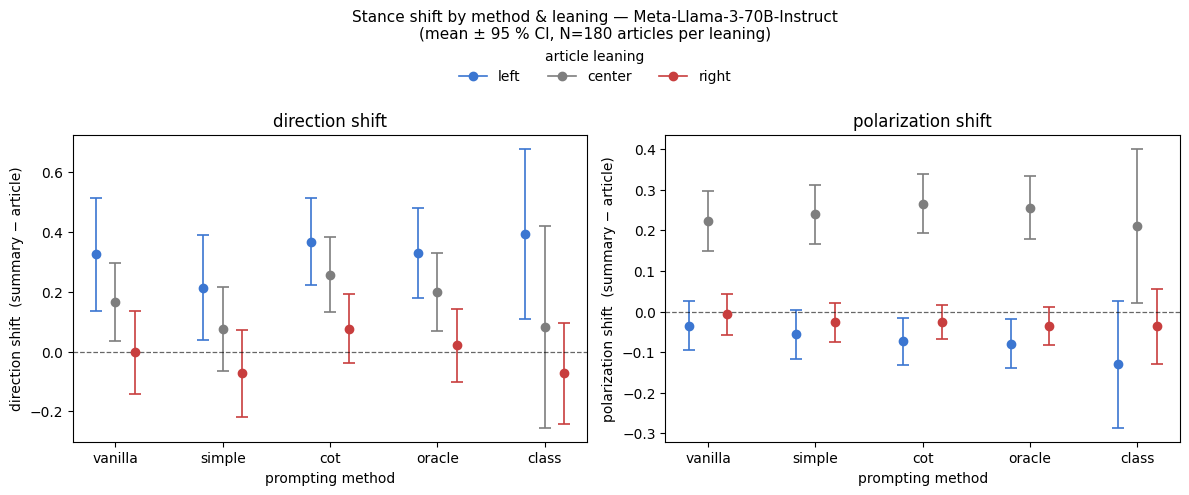

In [24]:
# ── 5.6  Plot: mean ± 95 % CI per (method, leaning) ─────────────────────
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

FIGURES_DIR = REPO_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LEANING_COLORS = {'left': '#3b76d1', 'center': '#7e7e7e', 'right': '#c83e3e'}
METHOD_PLOT_ORDER = ['vanilla', 'simple', 'cot', 'oracle', 'class']
x_pos  = {m: i for i, m in enumerate(METHOD_PLOT_ORDER)}
JITTER = {'left': -0.18, 'center': 0.0, 'right': 0.18}

PANEL_INFO = [
    ('direction_shift',    'direction shift  (summary − article)'),
    ('polarization_shift', 'polarization shift  (summary − article)'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (outcome, ylabel) in zip(axes, PANEL_INFO):
    for lean in ['left', 'center', 'right']:
        color = LEANING_COLORS[lean]
        xs, ys, errs = [], [], []
        for method in METHOD_PLOT_ORDER:
            sub  = llama_ag[(llama_ag['leaning'] == lean) &
                            (llama_ag['method']  == method)][outcome]
            n    = len(sub)
            mu   = sub.mean()
            se   = sub.std(ddof=1) / np.sqrt(n)
            xs.append(x_pos[method] + JITTER[lean])
            ys.append(mu)
            errs.append(1.96 * se)
        ax.errorbar(xs, ys, yerr=errs, fmt='o', color=color,
                    capsize=4, capthick=1.2, linewidth=1.2,
                    markersize=6, label=lean)

    ax.axhline(0, color='black', lw=0.9, ls='--', alpha=0.6)
    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels(METHOD_PLOT_ORDER)
    ax.set_xlabel('prompting method')
    ax.set_ylabel(ylabel)
    ax.set_title(outcome.replace('_', ' '))

handles = [
    mlines.Line2D([], [], color=LEANING_COLORS[l], marker='o',
                  linewidth=1.2, markersize=6, label=l)
    for l in ['left', 'center', 'right']
]
fig.legend(handles=handles, title='article leaning', loc='upper center',
           ncol=3, bbox_to_anchor=(0.5, 1.03), frameon=False)
# N per leaning (articles, not rows)
n_art = llama_ag.groupby('leaning')['article_id'].nunique()
n_str = '  |  '.join(f'{l[0].upper()}={n_art[l]}' for l in ['left', 'center', 'right'])
fig.suptitle(
    f'Stance shift by method & leaning — {LLAMA_ID}\n'
    f'(descriptive mean ± 95 % CI  [{n_str} articles]'
    ' — see model summaries and LR test for inference)',
    y=1.09, fontsize=10,
)
fig.tight_layout()

out_path = FIGURES_DIR / 'llama_stance_shift.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Figure saved → {out_path}')
plt.show()